### Kernel ==> moment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from PIL import Image
from io import BytesIO
import re
import json

import torch
from io import BytesIO
import h5py
from momentfm import MOMENTPipeline

/home/inpyo/anaconda3/envs/moment/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
moment_model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large", 
    model_kwargs={"task_name": "embedding"},
)
moment_model.init()

/home/inpyo/anaconda3/envs/moment/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_data(data_path):
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
        value_list = []
        label_list = []

        data_length = len(data['series'])

        for num in range(data_length):
            org_values = data['series'][num]
            values = [value[0] for value in org_values]

            org_answers = data['anom'][num]
            labels = [0 for _ in range(len(values))]
            for answer in org_answers[0]:
                start, end = answer[0], answer[1] # interval 
                labels[start:end] = [1 for _ in range(start, end)]

            value_list.append(values)
            label_list.append(labels)

    return value_list, label_list

def get_normal_set(normal_guide_bag, normal_caption_bag, value, model):
    length_list = [50*(i+1) for i in range(20)]
    min_value = 1000
    min_idx = 0
    for i in range(20):
        length = length_list[i]
        diff = abs(length-value)
        if abs(length-value) < min_value:
            min_value = diff
            min_idx = i

    optimal_length = length_list[min_idx]
    normal_guide_list = normal_guide_bag[min_idx]
    normal_caption_list = normal_caption_bag[min_idx]

    # get normal embedding
    normal_guide_tensor = torch.from_numpy(np.array(normal_guide_list))
    device = next(model.parameters()).device
    normal_guide_tensor = normal_guide_tensor.unsqueeze(1).float().to(device)
    normal_embedding = model(x_enc=normal_guide_tensor).embeddings # [n, 1024]

    return normal_caption_list, normal_embedding

def get_optimal_normal_guide(class_name, group, normal_caption_list, normal_embedding, model):
    # get group embedding

    device = next(model.parameters()).device

    group = np.array(group)
    mean_tensor = torch.from_numpy(np.mean(group, axis=0))
    mean_tensor = mean_tensor.view(1, 1, -1).float().to(device)
    mean_embedding = model(x_enc=mean_tensor).embeddings

    # find similarity
    similarity = -torch.norm(normal_embedding - mean_embedding, dim=1)
    most_similar_index = int(torch.argmax(similarity).cpu())

    optimal_normal_length = normal_caption_list['range']
    optimal_normal_caption = json.loads(normal_caption_list['desc'][most_similar_index])
    
    base_path = f'Guide/{class_name}/normal_range/{optimal_normal_length}'
    file_name_without_ext = f'{optimal_normal_length}_{most_similar_index}'
    
    optimal_normal_img_path = f'{base_path}/{file_name_without_ext}.png'
    caption_save_path = f'{base_path}/{file_name_without_ext}.json'

    os.makedirs(base_path, exist_ok=True)

    with open(caption_save_path, 'w', encoding='utf-8') as f:
        json.dump(optimal_normal_caption, f, indent=4)
        
    print(f"캡션 저장 완료: {caption_save_path}")

    optimal_normal_length = normal_caption_list['range']
    optimal_normal_caption = normal_caption_list['desc'][most_similar_index]
    optimal_normal_caption = json.loads(optimal_normal_caption)
    optimal_normal_img = f'Guide/{class_name}/normal_range/{optimal_normal_length}/{optimal_normal_length}_{most_similar_index}.png'

    return optimal_normal_caption, optimal_normal_img

def show_pil_image(image):
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    plt.close()
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def make_ts_image(length, values, label=None, show_gt=False):
    plt.clf()
    plt.figure(figsize=(12, 2))
    plt.plot([num for num in range(length)],[score for score in values]) 
    if show_gt:
        anomalies_idx = [i for i,l in enumerate(label) if l==1] 
        plt.bar(anomalies_idx, 2, bottom=-1, width=1, color='green',alpha=0.5, label='Ground-truth') 
    plt.tight_layout()
    
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight') 
    buf.seek(0)
    plt.close()
    pil_image = Image.open(buf)
    return pil_image

def make_ts_image_for_testing(length, values, predicted, label, precision, recall, f1score):
    predicted_idx = [i for i,l in enumerate(predicted) if l==1] 
    anomalies_idx = [i for i,l in enumerate(label) if l==1] 

    plt.clf()
    plt.figure(figsize=(24, 4))
    plt.plot([num for num in range(length)],[score for score in values]) 
    plt.bar(predicted_idx, 1, bottom=0, width=1, color='red',alpha=0.5, label=f'Predicted') 
    plt.bar(anomalies_idx, 2, bottom=-1, width=1, color='green',alpha=0.5, label='Ground-truth') 
    plt.plot([], [], ' ', label=f'Precision: {precision:.2f}')
    plt.plot([], [], ' ', label=f'Recall: {recall:.2f}')
    plt.plot([], [], ' ', label=f'F1 Score: {f1score:.2f}')
    plt.xlabel("Time", fontsize=20)
    plt.ylabel("Value", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    plt.legend(fontsize=24, loc='upper left')
    plt.tight_layout()
    
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight') 
    buf.seek(0)
    plt.close()
    pil_image = Image.open(buf)
    return pil_image

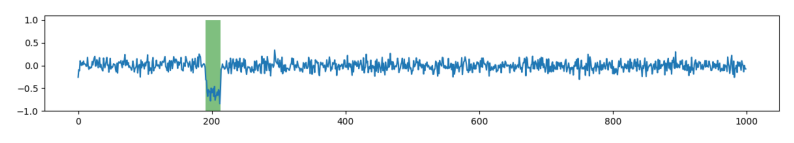

In [4]:
data_type = 'range'
data_path = f'/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/{data_type}/eval/data.pkl'
value_list, label_list = get_data(data_path)
test_num = 70
test_length = len(label_list[test_num])
test_label = label_list[test_num]
test_values = value_list[test_num]
test_image = make_ts_image(test_length, test_values, test_label, True)
show_pil_image(test_image)

/home/inpyo/anaconda3/envs/moment/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/inpyo/anaconda3/envs/moment/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


캡션 저장 완료: Guide/range/normal_range/1000/1000_0.json


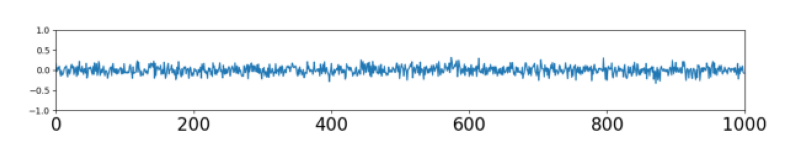

{'trend': 'The trend component is nearly flat, indicating a stable and consistent level over time.', 'seasonality': 'The seasonal component exhibits a clear periodic pattern with a period of 40, showing regular fluctuations that repeat every 40 time units.', 'shape': 'The overall shape of the time series is relatively flat with minor fluctuations.', 'state': 'The data appears to be stable with minor variations, suggesting a lack of significant changes or anomalies.'}


In [5]:
normal_guide_path = f'/home/inpyo/inpyo/Code-LMTAD-main/Guide/{data_type}/normal_feature.h5'
normal_caption_path = f'/home/inpyo/inpyo/Code-LMTAD-main/Guide/{data_type}/normal_guide.json'



with h5py.File(normal_guide_path, 'r') as file:
    normal_guide_bag = []
    for i in range(len(file)):
        normal_guide_bag.append(file[str(i)][:])

with open(normal_caption_path, 'r') as file:
    normal_caption_bag = json.load(file)

normal_caption_list, normal_embedding = get_normal_set(normal_guide_bag, normal_caption_bag, test_length, moment_model)
group = [test_values]
normal_guide_caption, normal_guide_image = get_optimal_normal_guide(data_type, group, normal_caption_list, normal_embedding, moment_model)

show_pil_image(normal_guide_image)
print(normal_guide_caption)

In [6]:
def get_path_range_set(json_file_path='Guide/anomaly_guide.json'):
    path_range_set = []
    for i in range(20):
        range_list = []
        length = 50*(i+1)
        path = f'Guide/anomaly_guide_{50*(i+1)}.png'

        with open(json_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            item = data[(length//50)-1]
            for i in range(4):
                guide_range = json.loads(item[f'range_{i+1}'])
                range_list.append(guide_range)

        path_range_set.append((path, range_list))
    return path_range_set


def get_path_range(path_range_set, value):
    length_list = [50*(i+1) for i in range(20)]
    min_value = 1000
    min_idx = 0
    for i in range(20):
        length = length_list[i]
        diff = abs(length-value)
        if abs(length-value) < min_value:
            min_value = diff
            min_idx = i
    return path_range_set[min_idx]

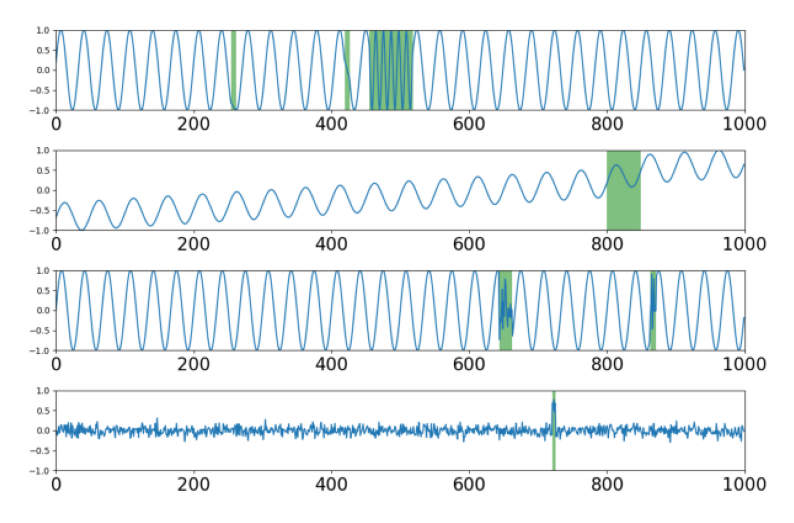

In [7]:
path_range_set = get_path_range_set()
path_range_list = get_path_range(path_range_set, test_length)
guide_path, range_list = path_range_list[0], path_range_list[1]
anomaly_guide_image = Image.open(guide_path)
show_pil_image(anomaly_guide_image)

In [8]:
def prompt_selection(baseline=True, guide_dict=None):
    if baseline:
        prompt = """\
        Detect ranges of anomalies in this time series, in terms of the x-axis coordinate.
        List one by one, in JSON format. 
        If there are no anomalies, answer with an empty list [].

        Output template:
        [{"start": ..., "end": ...}, {"start": ..., "end": ...}...]
        please do not provide any additional text or explanation.
        """

    # two guides inference
    else:
        prompt = f"""
        You are given three images.

        The first image serves as a visual guide, depicting a normal time series pattern based on the following description:
        {{
            "trend": {guide_dict['trend']},
            "seasonality": {guide_dict['seasonality']},
            "shape": {guide_dict['shape']},
            "state": {guide_dict['state']},
        }} 

        The second image is a visual guide showing four types of univariate time series anomalies.
        Each row corresponds to one anomaly type (from top to bottom): 
        (1) Frequency anomaly: unexpected changes in periodic patterns. 
        (2) Trend anomaly: changes in the gradient of the time series, such as acceleration, deceleration, or reversal. 
        (3) Point anomaly: individual points deviating significantly from the surrounding pattern. 
        (4) Out-of-range anomaly: values that strongly deviate from the normal range. 
        Green regions in the second image indicate the anomaly ranges for each type.

        The third image shows a univariate time series for anomaly detection.    

        Identify time ranges in the third image that deviate from the normal pattern shown in the first image, or that match any of the four anomaly types illustrated in the second image.  
        Return the detected anomaly ranges as a list of dictionaries, one per anomaly, in terms of the x-axis coordinate.
        If there are no anomalies, return an empty list [].
        
        Output format only: [{{"start": ..., "end": ...}}, {{"start": ..., "end": ...}}...] 
        Do not provide any additional explanation or text.
        """
    return prompt


def qwen_make_messages_one_image(prompt, image):
    messages = [
        {
            "role": "system", 
            "content": "You are a time series anomaly detector."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text", 
                    "text": prompt
                },
            ],
        }
    ]
    return messages


def qwen_make_messages_images(prompt, image1, image2, image3):
    messages = [
        {
            "role": "system", 
            "content": "You are a time series anomaly detector."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image1,
                },
                {
                    "type": "image",
                    "image": image2,
                },
                {
                    "type": "image",
                    "image": image3,
                },
                {
                    "type": "text", 
                    "text": prompt
                },
            ],
        }
    ]
    return messages

In [9]:
two_guides_prompt = prompt_selection(baseline=False, guide_dict = normal_guide_caption)
print(two_guides_prompt)


        You are given three images.

        The first image serves as a visual guide, depicting a normal time series pattern based on the following description:
        {
            "trend": The trend component is nearly flat, indicating a stable and consistent level over time.,
            "seasonality": The seasonal component exhibits a clear periodic pattern with a period of 40, showing regular fluctuations that repeat every 40 time units.,
            "shape": The overall shape of the time series is relatively flat with minor fluctuations.,
            "state": The data appears to be stable with minor variations, suggesting a lack of significant changes or anomalies.,
        } 

        The second image is a visual guide showing four types of univariate time series anomalies.
        Each row corresponds to one anomaly type (from top to bottom): 
        (1) Frequency anomaly: unexpected changes in periodic patterns. 
        (2) Trend anomaly: changes in the gradient of the ti